# Consolidación del Hito 1

**NovaMarket · Preprocesamiento de Datos · Grupo 05**

Integrantes: María Andrea Torres · Ricardo Borja · Gabriel Murillo Velandia · Laura Marcela Gómez

---

Este cuaderno consolida el trabajo de la Misión 1 en los insumos que alimentan el Informe de Calidad
de Datos y el Plan de Saneamiento. Reúne dos piezas que hasta ahora vivían separadas:

- La **auditoría de las seis dimensiones de calidad**, que produjo el catálogo de problemas.
- El **diagnóstico y tratamiento de valores faltantes**, con su tabla de decisiones por columna.

No introduce hallazgos nuevos. Lo que hace es **volver a calcular desde el archivo crudo cada cifra
que llega al informe**, con una comprobación automática que detiene la ejecución si algún resultado
no coincide, y ensamblar con ellas el catálogo definitivo.

### Productos de este cuaderno

| Archivo | Contenido |
|---|---|
| `S05_PD_Grupo05_CatalogoProblemas.xlsx` | Catálogo priorizado, resumen por dimensión, estrategia de faltantes y verificaciones no concluyentes |

### Fuentes

| Archivo | Aporta |
|---|---|
| `NovaMarket_datos_crudos.csv` | 640.000 registros × 20 variables, sin tratar |
| `S3_Grupo05_AuditoriaCalidad.ipynb` | Auditoría de las seis dimensiones |
| `S04_PD_Borja_EstrategiaFaltantes.ipynb` | Diagnóstico de mecanismo y tabla de decisiones |

## 1. Criterio de clasificación por dimensión

Antes de contar nada hay que fijar dónde va cada hallazgo, porque tres de las seis dimensiones se
confunden con facilidad y la frontera entre ellas no es obvia.

| Dimensión | Pregunta que responde | Ejemplo de este archivo |
|---|---|---|
| **Completitud** | ¿Falta el dato? | 105.312 pedidos sin correo; 5.698 fechas escritas como `00/00/0000` |
| **Unicidad** | ¿El registro está repetido? | 20.000 pedidos idénticos en las 20 columnas |
| **Validez** | ¿El valor rompe el **formato** del campo? | `cliente593809.hotmail.com` no tiene arroba; `30/02/2025` no existe en el calendario |
| **Consistencia** | ¿Se escribe siempre igual, y **coinciden los campos entre sí**? | 88 formas de escribir 12 ciudades; ciudad y código postal que se contradicen |
| **Exactitud** | ¿El valor está bien formado pero **rompe la realidad** que describe? | `-888100` es un número legible, pero un precio no puede ser negativo |
| **Oportunidad** | ¿El dato está vigente? | 16.485 pedidos fechados después del corte de la auditoría |

**La regla que resuelve la frontera entre validez y exactitud es una sola pregunta:** ¿el valor rompe
el *formato* del campo, o rompe la *realidad* que el campo describe? Un correo sin arroba no se puede
interpretar, y eso es validez. Un precio de $-888.100 se interpreta sin ninguna ambigüedad; lo que
falla es que un precio no puede ser negativo, y eso es exactitud. La contradicción entre dos campos
del mismo registro es consistencia.

In [1]:
import pandas as pd
import numpy as np
import unicodedata
import re
import matplotlib.pyplot as plt

RUTA_CRUDO = "../NovaMarket/NovaMarket_datos_crudos.csv"
RUTA_HALLAZGOS = "../NovaMarket/S3_Grupo05_CatalogoProblemas.xlsx"
TOTAL_FILAS = 640_000

df = pd.read_csv(RUTA_CRUDO, low_memory=False)
print(f"Archivo crudo: {df.shape[0]:,} filas x {df.shape[1]} columnas".replace(",", "."))
assert df.shape == (TOTAL_FILAS, 20), "El archivo crudo no tiene las dimensiones esperadas"

# Conversión numérica única, reutilizada en todo el cuaderno
precio = pd.to_numeric(df["precio_unitario"], errors="coerce")
unidades = pd.to_numeric(df["unidades_vendidas"], errors="coerce")
monto = pd.to_numeric(df["monto_compra"], errors="coerce")
edad = pd.to_numeric(df["edad_cliente"], errors="coerce")
peso = pd.to_numeric(df["peso_pedido_kg"], errors="coerce")

Archivo crudo: 640.000 filas x 20 columnas


## 2. Verificación de los hallazgos de exactitud

Las nueve reglas siguientes detectan valores que el intérprete lee sin problema alguno. Ninguna de
ellas falla por formato: fallan porque el número que expresan no puede existir en un comercio
minorista. Por eso pertenecen a exactitud y no a validez.

In [2]:
reglas_exactitud = {
    "monto_compra menor o igual a cero":           (monto <= 0,                      45_182),
    "peso superior a 100 kg":                       (peso > 100,                      32_045),
    "unidades vendidas menores o iguales a cero":   (unidades <= 0,                   27_877),
    "edad fuera del rango 0 a 120 anios":           ((edad < 0) | (edad > 120),       27_829),
    "precio unitario negativo":                     (precio < 0,                      19_629),
    "unidades atipicas en 5.000 y 9.999":           (unidades.isin([5_000, 9_999]),   18_526),
    "monto por encima de 1.000 millones":           (monto.abs() > 1_000_000_000,     16_158),
    "precio superior a 10 millones":                (precio > 10_000_000,              6_164),
    "precio superior a 100 millones":               (precio > 100_000_000,             3_050),
}

filas = []
for nombre, (mascara, esperado) in reglas_exactitud.items():
    obtenido = int(mascara.sum())
    assert obtenido == esperado, f"{nombre}: se obtuvo {obtenido}, se esperaba {esperado}"
    filas.append({"Regla": nombre, "Registros": obtenido,
                  "% del dataset": obtenido / TOTAL_FILAS})

verificacion_exactitud = pd.DataFrame(filas)
print("Las 9 reglas de dominio reproducen exactamente la cifra de la auditoría.\n")
verificacion_exactitud.style.format({"Registros": "{:,.0f}", "% del dataset": "{:.2%}"})

Las 9 reglas de dominio reproducen exactamente la cifra de la auditoría.



,Regla,Registros,% del dataset
0,monto_compra menor o igual a cero,"45,182",7.06%
1,peso superior a 100 kg,"32,045",5.01%
2,unidades vendidas menores o iguales a cero,"27,877",4.36%
3,edad fuera del rango 0 a 120 anios,"27,829",4.35%
4,precio unitario negativo,"19,629",3.07%
5,unidades atipicas en 5.000 y 9.999,"18,526",2.89%
6,monto por encima de 1.000 millones,"16,158",2.52%
7,precio superior a 10 millones,"6,164",0.96%
8,precio superior a 100 millones,"3,050",0.48%


## 3. Verificación de los hallazgos de validez

Solo dos hallazgos del archivo fallan por formato, y en ambos la cadena no se puede interpretar como
lo que el campo declara ser.

In [3]:
correo_sin_arroba = (df["correo_cliente"].notna()
                     & ~df["correo_cliente"].astype(str).str.contains("@", regex=False))

# La columna de fecha trae dos formatos mezclados, de modo que hay que probar los dos
# antes de declarar que un valor no es convertible.
_texto_fecha = df["fecha_pedido"].astype(str).str.strip()
_dmy = pd.to_datetime(_texto_fecha, format="%d/%m/%Y", errors="coerce")
_ymd = pd.to_datetime(_texto_fecha, format="%Y-%m-%d", errors="coerce")
fecha_no_convertible = _dmy.fillna(_ymd).isna()

print("Valores que no se pueden convertir a una fecha real:")
print(df.loc[fecha_no_convertible, "fecha_pedido"].value_counts().to_string())

hallazgos_validez = pd.DataFrame([
    {"Regla": "correo sin arroba, con la forma cliente593809.hotmail.com",
     "Registros": int(correo_sin_arroba.sum()), "Esperado": 51_532},
    {"Regla": "fecha no convertible a una fecha real",
     "Registros": int(fecha_no_convertible.sum()), "Esperado": 22_687},
])
for _, r in hallazgos_validez.iterrows():
    assert r["Registros"] == r["Esperado"], f"{r['Regla']}: {r['Registros']} != {r['Esperado']}"
print("\nAmbas reglas de formato reproducen la cifra de la auditoría.")
hallazgos_validez

Valores que no se pueden convertir a una fecha real:
fecha_pedido
00/00/0000    5698
31/04/2025    5688
30/02/2025    5675
2026-13-05    5626

Ambas reglas de formato reproducen la cifra de la auditoría.


,Regla,Registros,Esperado
0,"correo sin arroba, con la forma cliente593809....",51532,51532
1,fecha no convertible a una fecha real,22687,22687


## 4. Verificación del cruce entre ciudad y código postal

Este hallazgo no evalúa si un campo aislado es correcto: evalúa si **dos campos del mismo registro se
contradicen**, y por eso pertenece a consistencia. Los cinco primeros dígitos de `codigo_postal`
corresponden al código de municipio del DANE, de modo que el archivo trae la ciudad dos veces, una en
texto y otra codificada.

La verificación incluye un control sobre los nombres de municipio, que es el paso que evita inflar el
conteo cuando la normalización de ciudad no unifica todas las variantes.

In [4]:
def quitar_tildes(texto):
    if pd.isna(texto):
        return np.nan
    limpio = unicodedata.normalize("NFKD", str(texto)).encode("ascii", "ignore").decode()
    return re.sub(r"\s+", " ", limpio).strip().lower()


EQUIVALENCIAS = {
    "bog": "bogota", "bogota dc": "bogota", "bogota d c": "bogota", "santafe de bogota": "bogota",
    "mde": "medellin", "medellin, ant": "medellin",
    "ctg": "cartagena", "cartagena de indias": "cartagena",
    "baq": "barranquilla", "b/quilla": "barranquilla",
    "bga": "bucaramanga", "b/manga": "bucaramanga",
    "mzl": "manizales", "manizales, caldas": "manizales",
    "smr": "santa marta", "sta marta": "santa marta", "santamarta": "santa marta",
    "cli": "cali", "santiago de cali": "cali",
    "per": "pereira", "ctu": "cucuta", "cuc": "cucuta",
    "ibg": "ibague", "vvc": "villavicencio", "pas": "pasto",
}


def normalizar_ciudad(texto):
    base = quitar_tildes(texto)
    if base is np.nan:
        return np.nan
    return EQUIVALENCIAS.get(base.replace(".", ""), base.replace(".", ""))


df["ciudad_norm"] = df["ciudad_tienda"].map(normalizar_ciudad)
df["municipio_dane"] = (df["codigo_postal"].astype(str)
                        .str.extract(r"(\d+)")[0].str.zfill(7).str[:5])

con_ciudad = df.dropna(subset=["ciudad_norm"])
ciudades = sorted(con_ciudad["ciudad_norm"].unique())
print(f"Variantes de escritura en el archivo crudo: {df['ciudad_tienda'].nunique()}")
print(f"Ciudades reales tras normalizar: {len(ciudades)}")
print(", ".join(ciudades))

referencia = con_ciudad.groupby("ciudad_norm")["municipio_dane"].agg(
    lambda s: s.value_counts().idxmax())
assert referencia.nunique() == len(ciudades), "Dos ciudades distintas comparten el mismo código DANE"

discrepancia = con_ciudad["municipio_dane"] != con_ciudad["ciudad_norm"].map(referencia)
n_discrepancia = int(discrepancia.sum())
print(f"\nRegistros con ciudad y municipio DANE contradictorios: "
      f"{n_discrepancia:,}".replace(",", "."))
assert n_discrepancia == 42_405

Variantes de escritura en el archivo crudo: 88
Ciudades reales tras normalizar: 12
barranquilla, bogota, bucaramanga, cali, cartagena, cucuta, ibague, manizales, medellin, pereira, santa marta, villavicencio



Registros con ciudad y municipio DANE contradictorios: 42.405


## 5. Verificaciones que no arrojaron un veredicto concluyente

Tres comprobaciones de la auditoría no permiten concluir si el dato es correcto o incorrecto, puesto
que **no existe una referencia contra la cual contrastarlo**. Su cifra es siempre el complemento de
las reglas que sí detectan errores, es decir, describe el alcance de lo que quedó sin verificar.

No son problemas de calidad y por eso no forman parte del catálogo. Se documentan aparte, porque
delimitan hasta dónde llegó la auditoría, que es información que el comité necesita para saber cuánto
pesa el dictamen.

In [5]:
# Precio: no hay una referencia por artículo contra la cual validar
sin_precio, precio_negativo = precio.isna(), precio < 0
precio_sobre_tope = precio > 10_000_000
alcance_precio = TOTAL_FILAS - int((sin_precio | precio_negativo | precio_sobre_tope).sum())
print("Alcance de la verificación de precio")
print(f"  640.000 - ({int(sin_precio.sum()):,} sin dato + {int(precio_negativo.sum()):,} negativos "
      f"+ {int(precio_sobre_tope.sum()):,} sobre 10 millones) = {alcance_precio:,}".replace(",", "."))
assert alcance_precio == 592_567

# Peso: tampoco hay referencia por artículo ni por cantidad
alcance_peso = TOTAL_FILAS - int((peso > 100).sum())
print(f"\nAlcance de la verificación de peso")
print(f"  640.000 - {int((peso > 100).sum()):,} sobre 100 kg = {alcance_peso:,}".replace(",", "."))
assert alcance_peso == 607_955

# Fecha de stock: solo 995 registros son contrastables. Cifra tomada de la auditoría.
alcance_stock = 639_005
print(f"\nAlcance de la verificación de fecha de stock: {alcance_stock:,}".replace(",", "."))

verificaciones_no_concluyentes = pd.DataFrame([
    {"Columna": "precio_unitario, producto", "Alcance": alcance_precio,
     "Motivo": "El producto explica una fracción despreciable de la varianza del precio "
               "(eta cuadrado = 0,000026) y ninguno de los 120 grupos de producto y cantidad tiene "
               "un precio único. No hay referencia contra la cual comparar."},
    {"Columna": "peso_pedido_kg", "Alcance": alcance_peso,
     "Motivo": "Eta cuadrado de 0,000046 frente al producto y correlación de -0,0009 frente a las "
               "unidades vendidas. Una bicicleta estática pesa en promedio lo mismo que una bufanda."},
    {"Columna": "fecha_actualizacion_stock", "Alcance": alcance_stock,
     "Motivo": "Solo 995 registros tienen una fecha de stock contrastable, sobre 7.406 grupos de "
               "sede y producto. El hallazgo es de comportamiento de la columna, no un conteo de "
               "registros erróneos."},
])
verificaciones_no_concluyentes["% del dataset"] = (
    verificaciones_no_concluyentes["Alcance"] / TOTAL_FILAS)
verificaciones_no_concluyentes

Alcance de la verificación de precio
  640.000 - (21.640 sin dato + 19.629 negativos + 6.164 sobre 10 millones) = 592.567

Alcance de la verificación de peso
  640.000 - 32.045 sobre 100 kg = 607.955

Alcance de la verificación de fecha de stock: 639.005


,Columna,Alcance,Motivo,% del dataset
0,"precio_unitario, producto",592567,El producto explica una fracción despreciable ...,0.925886
1,peso_pedido_kg,607955,"Eta cuadrado de 0,000046 frente al producto y ...",0.949930
2,fecha_actualizacion_stock,639005,Solo 995 registros tienen una fecha de stock c...,0.998445


## 6. Verificación de los hallazgos de completitud sobre el correo

El correo es la columna que concentra el mayor volumen de faltantes del archivo y, a la vez, tiene un
hallazgo de exactitud sobre la misma columna. Los dos se verifican juntos porque su lectura conjunta
cambia la conclusión.

In [6]:
correo_faltante = int(df["correo_cliente"].isna().sum())
print(f"Registros sin correo: {correo_faltante:,} "
      f"({correo_faltante / TOTAL_FILAS:.2%})".replace(",", "."))
assert correo_faltante == 105_312

con_correo = df[df["correo_cliente"].notna()].copy()
numero_en_correo = con_correo["correo_cliente"].astype(str).str.extract(r"cliente(\d+)@")[0]
numero_pedido = con_correo["id_pedido"].astype(str).str.extract(r"(\d+)")[0]
coincide = (pd.to_numeric(numero_en_correo, errors="coerce")
            == pd.to_numeric(numero_pedido, errors="coerce") - 100_000)
print(f"El número del correo es id_pedido - 100.000 en el {coincide.mean():.2%} "
      "de los registros que sí tienen correo")

clientes_multiples = con_correo.groupby("id_cliente")["correo_cliente"].nunique()
print(f"Clientes con más de un correo distinto: "
      f"{int((clientes_multiples > 1).sum()):,}".replace(",", "."))

Registros sin correo: 105.312 (16.46%)


El número del correo es id_pedido - 100.000 en el 90.36% de los registros que sí tienen correo


Clientes con más de un correo distinto: 131.213


**Lectura conjunta.** Los 105.312 correos vacíos son el faltante de mayor volumen del archivo y tienen
consecuencia comercial directa, puesto que ese 16,46% de pedidos no puede recibir comunicación
posventa. Pero el problema de fondo es mayor: la columna **identifica la transacción y no a la
persona**, de modo que no funciona como dato de contacto en ningún registro, ni siquiera en los que sí
tienen valor. El faltante es un problema de severidad media; la columna entera es un problema de
severidad alta.

## 7. Construcción del catálogo de problemas

Los hallazgos verificados arriba se ensamblan con el resto de la auditoría en un catálogo único,
ordenado de mayor a menor severidad y con una columna de impacto en el negocio por cada fila.

In [7]:
hallazgos = pd.read_excel(RUTA_HALLAZGOS)
hallazgos = hallazgos[["Dimensión", "Columna afectada", "Descripción del problema",
                       "Registros afectados", "% del dataset", "Severidad"]].copy()
hallazgos["idx"] = range(len(hallazgos))
print(f"Hallazgos registrados durante la auditoría: {len(hallazgos)}")

# Dimensión asignada según el criterio de la sección 1
DIMENSION = {19: "Exactitud", 21: "Exactitud", 23: "Exactitud", 24: "Exactitud",
             29: "Exactitud", 30: "Exactitud", 31: "Exactitud", 32: "Exactitud",
             34: "Exactitud", 20: "Consistencia"}

# Filas que corresponden a verificaciones no concluyentes, no a problemas
NO_CONCLUYENTES = [1, 10, 11]

# Severidad asignada por volumen e impacto comercial
SEVERIDAD = {35: "Media"}

DESCRIPCION = {
    35: ("Registros sin correo electrónico. Es el faltante de mayor volumen del archivo. Cada "
         "registro sin correo es un pedido que no puede recibir comunicación posventa ni entrar en "
         "una campaña de correo."),
}

assert len(hallazgos) == 38
assert set(hallazgos.loc[[19, 21, 23, 24, 29, 30, 31, 32, 34], "Dimensión"]) == {"Validez"}
assert int(hallazgos.loc[35, "Registros afectados"]) == 105_312
print("Los índices de trabajo corresponden a las filas esperadas.")

Hallazgos registrados durante la auditoría: 38
Los índices de trabajo corresponden a las filas esperadas.


In [8]:
catalogo = hallazgos[~hallazgos["idx"].isin(NO_CONCLUYENTES)].copy()
catalogo["Dimensión"] = [DIMENSION.get(i, d)
                         for i, d in zip(catalogo["idx"], catalogo["Dimensión"])]
catalogo["Severidad"] = [SEVERIDAD.get(i, s)
                         for i, s in zip(catalogo["idx"], catalogo["Severidad"])]
catalogo["Descripción del problema"] = [
    DESCRIPCION.get(i, d) for i, d in zip(catalogo["idx"], catalogo["Descripción del problema"])]

orden = {"Alta": 0, "Media": 1, "Baja": 2}
catalogo = (catalogo.assign(_o=catalogo["Severidad"].map(orden))
            .sort_values(["_o", "Registros afectados"], ascending=[True, False])
            .drop(columns="_o").reset_index(drop=True))

assert len(catalogo) == 35
assert catalogo["Severidad"].tolist() == sorted(catalogo["Severidad"], key=orden.get)
print(f"Catálogo: {len(catalogo)} problemas, ordenados de mayor a menor severidad.")

Catálogo: 35 problemas, ordenados de mayor a menor severidad.


In [9]:
resumen_dim = (catalogo.groupby("Dimensión")
               .agg(Problemas=("Severidad", "size"),
                    Registros=("Registros afectados", "sum"),
                    Alta=("Severidad", lambda s: (s == "Alta").sum()))
               .reindex(["Completitud", "Unicidad", "Validez",
                         "Consistencia", "Exactitud", "Oportunidad"]))
resumen_sev = catalogo["Severidad"].value_counts().reindex(["Alta", "Media", "Baja"])

print("Problemas por dimensión\n")
print(resumen_dim.to_string())
print(f"\nTotal: {len(catalogo)} problemas · "
      f"{int(catalogo['Registros afectados'].sum()):,} registros afectados".replace(",", "."))
print("\n\nProblemas por severidad\n")
print(resumen_sev.to_string())

Problemas por dimensión

              Problemas  Registros  Alta
Dimensión                               
Completitud           7     321493     0
Unicidad              1      20000     0
Validez               2      74219     0
Consistencia          6    1041825     5
Exactitud            12    1613170     3
Oportunidad           7     770386     1

Total: 35 problemas · 3.841.093 registros afectados


Problemas por severidad

Severidad
Alta      9
Media    24
Baja      2


Exactitud es la dimensión más cargada del archivo, y eso no es casual: los defectos de NovaMarket no
están en cómo se escriben los valores sino en lo que esos valores afirman sobre la operación. Solo
dos hallazgos rompen el formato de un campo; el resto describe cosas que no pudieron ocurrir.

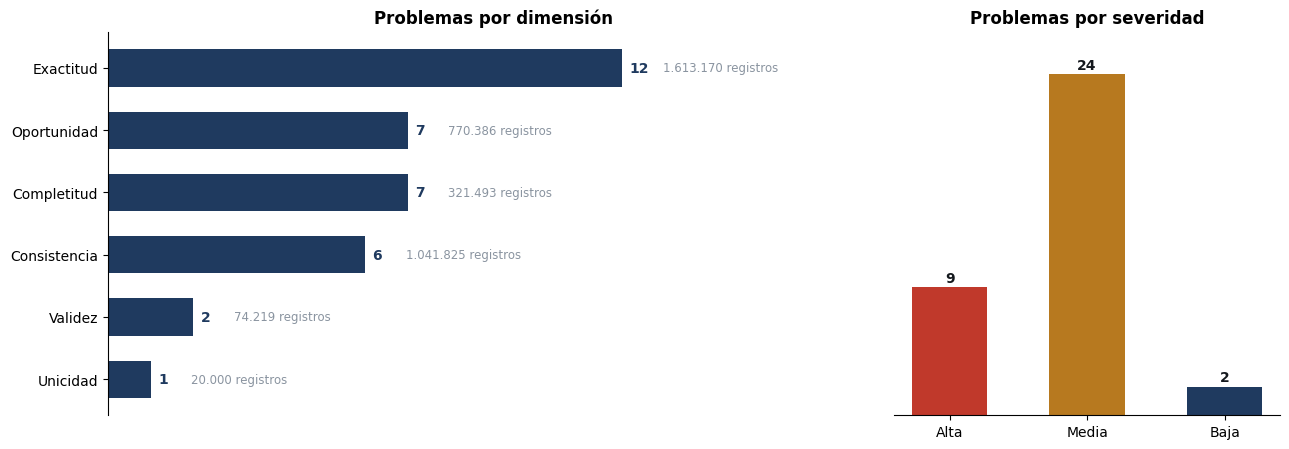

In [10]:
AZUL, ROJO, AMBAR, GRIS, TINTA = "#1F3A5F", "#C0392B", "#B7791F", "#8A94A0", "#14181D"
plt.rcParams.update({"font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
                     "figure.facecolor": "white", "axes.facecolor": "white"})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [2, 1]})

d = resumen_dim.sort_values("Problemas")
y = np.arange(len(d))
ax1.barh(y, d["Problemas"].values, color=AZUL, height=.6)
for i, (n, reg) in enumerate(zip(d["Problemas"].values, d["Registros"].values)):
    ax1.text(n + .18, i, f"{n}", va="center", fontweight="bold", color=AZUL, fontsize=10)
    ax1.text(n + .95, i, f"{reg:,}".replace(",", ".") + " registros",
             va="center", color=GRIS, fontsize=8.5)
ax1.set_yticks(y); ax1.set_yticklabels(d.index)
ax1.set_xlim(0, d["Problemas"].max() + 6)
ax1.set_title("Problemas por dimensión")
ax1.set_xticks([])
for lado in ("top", "right", "bottom"):
    ax1.spines[lado].set_visible(False)

niveles = ["Alta", "Media", "Baja"]
ax2.bar(niveles, resumen_sev.values, color=[ROJO, AMBAR, AZUL], width=.55)
for i, v in enumerate(resumen_sev.values):
    ax2.text(i, v + .4, str(v), ha="center", fontweight="bold", color=TINTA)
ax2.set_title("Problemas por severidad")
ax2.set_ylim(0, resumen_sev.max() + 3)
ax2.set_yticks([])
for lado in ("top", "right", "left"):
    ax2.spines[lado].set_visible(False)

fig.tight_layout()
plt.show()

## 8. Estrategia de valores faltantes

La auditoría de dimensiones dice **cuánto falta**. El diagnóstico de mecanismo dice **por qué falta**,
que es la pregunta que determina si una imputación es válida o si introduce sesgo.

| Mecanismo | Qué significa | ¿Se puede probar desde el archivo? |
|---|---|---|
| **MCAR** | La probabilidad de que falte no depende de nada | Solo se puede refutar |
| **MAR** | Depende de otra variable observada, no del valor ausente | Sí, es el único que se demuestra directamente |
| **MNAR** | Depende del propio valor que falta | No, exige conocimiento del negocio o datos externos |

**La advertencia que gobierna toda la tabla:** cuando ninguna variable observada explica la ausencia,
el resultado es compatible **a la vez con MCAR y con MNAR**. Lo único que esa evidencia descarta es
MAR. Por eso esos casos se rotulan como *MCAR aparente, MNAR no descartable* y no como MCAR a secas,
y por eso la acción tomada en ellos es la conservadora.

In [11]:
# Tabla de decisiones construida en S04_PD_Borja_EstrategiaFaltantes.ipynb.
# Las cifras corresponden al archivo ya deduplicado, de 620.000 filas.
TOTAL_DEDUP = 620_000

decisiones = pd.DataFrame([
 {"Columna": "correo_cliente", "Faltantes": 102_000, "Mecanismo": "MCAR aparente, MNAR no descartable",
  "Evidencia": "AUC 0,502; sin asociación con ninguna variable observada",
  "Estrategia": "Marcar como «desconocido» y no imputar",
  "Justificación": "Inventar una dirección de correo no aporta información y crearía la ilusión de "
                   "una base de contacto que no existe."},
 {"Columna": "comentario_cliente", "Faltantes": 88_000, "Mecanismo": "MNAR por diseño",
  "Evidencia": "AUC 0,505; el comentario es opcional por definición del formulario",
  "Estrategia": "Marcar como «sin comentario» y no imputar",
  "Justificación": "La ausencia es informativa en sí misma: no comentar es una respuesta, no un dato "
                   "perdido."},
 {"Columna": "nivel_satisfaccion", "Faltantes": 45_000, "Mecanismo": "MAR demostrado",
  "Evidencia": "canal_compra V de Cramér = 0,291 con p < 0,001; AUC 0,743; App 20,36% frente a "
               "2,8% a 3,0% en los otros tres canales",
  "Estrategia": "Categoría explícita «Sin dato» más columna indicadora",
  "Justificación": "Imputar un nivel fabricaría una opinión que el cliente nunca dio. Como la "
                   "satisfacción se distribuye igual en los cuatro canales, imputar condicionando en "
                   "el canal daría casi lo mismo que la moda global y ocultaría que en App falta uno "
                   "de cada cinco."},
 {"Columna": "ciudad_tienda", "Faltantes": 29_000, "Mecanismo": "MCAR aparente",
  "Evidencia": "AUC 0,503; ningún contraste supera V = 0,01",
  "Estrategia": "Imputación por deducción desde el código postal",
  "Justificación": "No es una estimación sino una recuperación exacta: los cinco primeros dígitos "
                   "del código postal son el municipio DANE y la columna está completa al 100%. "
                   "Cubre los 29.000 faltantes sin excepción."},
 {"Columna": "precio_unitario", "Faltantes": 21_000, "Mecanismo": "MCAR aparente, MNAR no descartable",
  "Evidencia": "AUC 0,493; sin asociación con ninguna variable observada",
  "Estrategia": "No imputar. Se deja nulo más columna indicadora",
  "Justificación": "La auditoría midió eta cuadrado = 0,000026 entre precio y producto: el artículo "
                   "no explica el precio, de modo que no existe una referencia de la cual partir. "
                   "Imputar con la mediana global asignaría el mismo precio a una bicicleta estática "
                   "y a una bufanda."},
 {"Columna": "monto_compra", "Faltantes": 21_000, "Mecanismo": "Estructural, derivado",
  "Evidencia": "Intersección exacta de 21.000 con precio_unitario, sin una sola excepción",
  "Estrategia": "No imputar. Se deja nulo más columna indicadora",
  "Justificación": "monto = precio × unidades se cumple en el 100% de los registros evaluables, de "
                   "modo que el vacío del monto es consecuencia del vacío del precio y se trata "
                   "igual que su causa."},
 {"Columna": "fecha_pedido", "Faltantes": 5_534, "Mecanismo": "MCAR aparente, MNAR no descartable",
  "Evidencia": "AUC 0,496; sin asociación con ninguna variable observada",
  "Estrategia": "No imputar. Nulo real más columna indicadora",
  "Justificación": "Provienen del centinela 00/00/0000. Inventar una fecha desplazaría pedidos en la "
                   "serie temporal, que es justo lo que la columna debe sostener."},
])
decisiones["% faltante"] = decisiones["Faltantes"] / TOTAL_DEDUP

assert len(decisiones) == 7
print(f"Columnas con valores faltantes: {len(decisiones)}")
print(f"Mecanismos diagnosticados: {decisiones['Mecanismo'].nunique()}")
print(f"\nDe las {len(decisiones)} columnas, solo {int((decisiones['Estrategia'].str.startswith('Imputación')).sum())} "
      "se imputa, y por deducción exacta, no por estimación.")
decisiones[["Columna", "Faltantes", "% faltante", "Mecanismo", "Estrategia"]].style.format(
    {"Faltantes": "{:,.0f}", "% faltante": "{:.2%}"})

Columnas con valores faltantes: 7
Mecanismos diagnosticados: 5

De las 7 columnas, solo 1 se imputa, y por deducción exacta, no por estimación.


,Columna,Faltantes,% faltante,Mecanismo,Estrategia
0,correo_cliente,"102,000",16.45%,"MCAR aparente, MNAR no descartable",Marcar como «desconocido» y no imputar
1,comentario_cliente,"88,000",14.19%,MNAR por diseño,Marcar como «sin comentario» y no imputar
2,nivel_satisfaccion,"45,000",7.26%,MAR demostrado,Categoría explícita «Sin dato» más columna indicadora
3,ciudad_tienda,"29,000",4.68%,MCAR aparente,Imputación por deducción desde el código postal
4,precio_unitario,"21,000",3.39%,"MCAR aparente, MNAR no descartable",No imputar. Se deja nulo más columna indicadora
5,monto_compra,"21,000",3.39%,"Estructural, derivado",No imputar. Se deja nulo más columna indicadora
6,fecha_pedido,"5,534",0.89%,"MCAR aparente, MNAR no descartable",No imputar. Nulo real más columna indicadora


**Por qué las cifras de esta tabla no coinciden con las del catálogo.** El diagnóstico de faltantes se
hizo sobre el archivo **ya deduplicado, de 620.000 filas**, mientras que la auditoría de dimensiones
se hizo sobre el archivo **crudo, de 640.000**. Por eso el correo aparece con 102.000 faltantes aquí y
con 105.312 en el catálogo: son los mismos registros medidos antes y después de eliminar los 20.000
pedidos duplicados. No es una discrepancia, es una diferencia de base declarada.

**La conclusión de método más importante de esta tabla:** de las siete columnas con vacíos, **solo una
se imputa**, y ni siquiera por estimación sino por deducción exacta desde el código postal. En las
otras seis la decisión fue marcar y no inventar. Un tratamiento de faltantes que imputa poco no es un
tratamiento incompleto: es un tratamiento que se niega a fabricar información que no existe.

## 9. Exportación del catálogo

El archivo `S05_PD_Grupo05_CatalogoProblemas.xlsx` se genera desde este cuaderno, de modo que cada fila
queda trazable a la celda que la produjo. Contiene cuatro hojas: el catálogo priorizado con la columna
de impacto en el negocio, el resumen por dimensión, la tabla de decisiones de valores faltantes y las
verificaciones no concluyentes.

In [12]:
IMPACTO = {
 0:  "Ninguna segmentación por edad es defendible. Marketing no puede construir audiencias por rango etario ni justificar el presupuesto de campañas dirigidas.",
 2:  "La base de contacto no existe como tal. Marketing no puede ejecutar campañas por correo ni medir apertura, porque cada compra genera una dirección distinta.",
 3:  "El informe de venta por ciudad reparte una misma sede en hasta siete filas distintas, de modo que Operaciones no puede comparar desempeño entre tiendas ni asignar inventario.",
 4:  "El reporte por categoría subdivide líneas reales, lo que impide a Compras negociar volumen con proveedores sobre cifras consolidadas.",
 5:  "El indicador de fuga no sirve como variable objetivo. Cualquier modelo de retención se entrenaría sobre una etiqueta que se contradice a sí misma.",
 6:  "La medición de rentabilidad por canal queda fragmentada, de modo que no se puede decidir dónde invertir el presupuesto de captación.",
 7:  "Finanzas no puede conciliar el recaudo por medio de pago ni estimar el costo real de las comisiones de tarjeta.",
 8:  "El indicador de satisfacción se reparte en clases que en realidad son la misma, de modo que Servicio al Cliente reporta un nivel que no corresponde a la realidad.",
 9:  "Las series de venta incluyen pedidos fechados en 2027, lo que infla la proyección de cierre de año que Finanzas presenta a la Junta.",
 12: "Impide medir latencia de inventario y rotación, de modo que Logística no puede dimensionar el stock de seguridad.",
 13: "El recuento de inventario que respalda el pedido es anterior a la compra, lo que hace inauditable la disponibilidad en el momento de la venta.",
 14: "Pedidos que se apoyan en un recuento antiguo, lo que aumenta el riesgo de vender sin existencias.",
 15: "Un año completo sin registros de stock rompe cualquier comparación interanual de inventario.",
 16: "El dato de inventario deja de ser confiable para reposición pasado ese plazo, con riesgo directo de quiebre de stock.",
 17: "Los correos con punto en lugar de arroba rebotan al enviarse, de modo que Marketing pierde alcance real en cada campaña.",
 18: "Se pierde la observación en todo cruce de satisfacción, y la ausencia se concentra en el canal App, lo que sesgaría la lectura si se ignora.",
 19: "45.182 pedidos restan en lugar de sumar al ingreso, de modo que el total de ventas que reporta Finanzas queda subestimado.",
 20: "La asignación de pedidos a zona de despacho es incorrecta en 42.405 casos, lo que le cuesta a Logística rutas mal planeadas y entregas fuera de zona.",
 21: "Los pesos de hasta 1.399 kg distorsionan el costo de flete estimado y hacen inservible cualquier cotización de transporte.",
 22: "Rompe la segmentación geográfica, aunque es recuperable de forma exacta desde el código postal del mismo registro.",
 23: "Las unidades negativas se mezclan con devoluciones legítimas, de modo que no se puede medir rotación de producto.",
 24: "Los perfiles con edad negativa o de 200 años contaminan cualquier segmentación demográfica de Marketing.",
 25: "Cuatro fechas imposibles impiden construir la serie temporal de venta sin descartar esos pedidos.",
 26: "Entra en cálculos monetarios, de modo que imputarlo con la media distorsionaría el ingreso reportado.",
 27: "Son exactamente las mismas filas que precio_unitario, de modo que el ingreso de esos pedidos no se puede reconstruir.",
 28: "Veinte mil pedidos contados dos veces inflan el ingreso y el número de transacciones en 3,12%.",
 29: "El precio negativo arrastra el error a monto_compra y al margen por producto que revisa Finanzas.",
 30: "Dos valores centinela inflan el volumen vendido y distorsionan la proyección de reposición de inventario.",
 31: "Dieciséis mil tickets por encima de mil millones desplazan cualquier promedio de ticket que se use para fijar metas comerciales.",
 32: "El tope repetido de 999 millones es un valor centinela, no un precio, y contamina el ingreso por artículo.",
 33: "Faltante disfrazado de texto. El conteo tradicional de nulos lo reporta como completo, lo que da una falsa sensación de calidad del dato.",
 34: "Subconjunto del anterior, con el mismo efecto sobre el ingreso por artículo.",
 35: "El 16,46% de los pedidos no tiene dirección de contacto, lo que reduce en la misma proporción el alcance de cualquier campaña de correo de Marketing.",
 36: "Texto libre opcional. Su ausencia reduce la muestra para análisis de voz del cliente, sin afectar ninguna cifra.",
 37: "Fechas de inventario posteriores al corte que impiden cerrar el periodo con cifras estables.",
}

catalogo["Impacto en el negocio"] = [IMPACTO[i] for i in catalogo["idx"]]
assert catalogo["Impacto en el negocio"].notna().all()
print(f"Los {len(catalogo)} problemas tienen impacto en el negocio redactado.")

Los 35 problemas tienen impacto en el negocio redactado.


In [13]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

SALIDA = "S05_PD_Grupo05_CatalogoProblemas.xlsx"
AZUL_X, ROJO_X, AMBAR_X, VERDE_X = "1F3A5F", "C0392B", "B7791F", "1E6F5C"
SUAVE, LINEA, GRIS_X = "EEF3F8", "C3D0DD", "5B6B7C"
COLOR_SEV = {"Alta": ROJO_X, "Media": AMBAR_X, "Baja": VERDE_X}
_l = Side(style="thin", color=LINEA)
BORDE = Border(left=_l, right=_l, top=_l, bottom=_l)


def _encabezado(ws, fila, titulos, anchos):
    for j, (t, a) in enumerate(zip(titulos, anchos), start=1):
        c = ws.cell(row=fila, column=j, value=t)
        c.font = Font(size=11, bold=True, color="FFFFFF")
        c.fill = PatternFill("solid", fgColor=AZUL_X)
        c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        c.border = BORDE
        ws.column_dimensions[get_column_letter(j)].width = a
    ws.row_dimensions[fila].height = 30


def _titulo(ws, texto, sub, ncol):
    ws.cell(row=1, column=1, value=texto).font = Font(size=15, bold=True, color=AZUL_X)
    ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=ncol)
    ws.cell(row=2, column=1, value=sub).font = Font(size=10, italic=True, color=GRIS_X)
    ws.merge_cells(start_row=2, start_column=1, end_row=2, end_column=ncol)
    ws.row_dimensions[1].height = 22


def _fila(ws, r, valores, centradas, envolver, cebra, alto=None):
    for j, v in enumerate(valores, start=1):
        c = ws.cell(row=r, column=j, value=v)
        c.font = Font(size=10)
        c.border = BORDE
        c.alignment = Alignment(horizontal="center" if j in centradas else "left",
                                vertical="top", wrap_text=j in envolver)
        if cebra:
            c.fill = PatternFill("solid", fgColor=SUAVE)
    if alto:
        ws.row_dimensions[r].height = alto


wb = Workbook()

# --- Hoja 1: catálogo de problemas
ws = wb.active
ws.title = "Catálogo de problemas"
_titulo(ws, "NovaMarket · Catálogo de problemas de calidad de datos",
        f"{len(catalogo)} problemas identificados sobre {TOTAL_FILAS:,} registros, ordenados de mayor "
        "a menor severidad.".replace(",", "."), 8)
_encabezado(ws, 4, ["N°", "Dimensión", "Columna afectada", "Descripción del problema",
                    "Registros afectados", "% del dataset", "Severidad", "Impacto en el negocio"],
            [5, 14, 24, 62, 15, 12, 11, 62])
r = 5
for k, row in catalogo.iterrows():
    _fila(ws, r, [k + 1, row["Dimensión"], row["Columna afectada"],
                  row["Descripción del problema"], int(row["Registros afectados"]),
                  row["% del dataset"], row["Severidad"], row["Impacto en el negocio"]],
          centradas={1, 2, 5, 6, 7}, envolver={3, 4, 8}, cebra=(k % 2 == 0), alto=46)
    ws.cell(row=r, column=5).number_format = "#,##0"
    ws.cell(row=r, column=6).number_format = "0.00%"
    ws.cell(row=r, column=7).font = Font(size=10, bold=True, color=COLOR_SEV[row["Severidad"]])
    r += 1
ultima = r - 1
ws.cell(row=r + 1, column=3, value="Total de problemas:").font = Font(bold=True, size=11)
ws.cell(row=r + 1, column=5, value=f"=COUNTA(D5:D{ultima})").font = Font(bold=True, size=11)
ws.cell(row=r + 2, column=3, value="Total de filas auditadas:").font = Font(bold=True, size=11)
ws.cell(row=r + 2, column=5, value=TOTAL_FILAS).font = Font(bold=True, size=11)
ws.cell(row=r + 2, column=5).number_format = "#,##0"
nota = ws.cell(row=r + 4, column=1, value=(
    "Nota. Un mismo registro puede estar afectado por varios problemas a la vez, por lo que la suma "
    "de registros afectados excede el total de filas auditadas. Las verificaciones que no arrojaron "
    "un veredicto concluyente están en su propia hoja y no cuentan como problemas."))
nota.font = Font(size=9, italic=True, color=GRIS_X)
nota.alignment = Alignment(wrap_text=True, vertical="top")
ws.merge_cells(start_row=r + 4, start_column=1, end_row=r + 5, end_column=8)
ws.freeze_panes = "A5"
ws.sheet_view.showGridLines = False
ws.auto_filter.ref = f"A4:H{ultima}"

# --- Hoja 2: resumen por dimensión
ws2 = wb.create_sheet("Resumen por dimensión")
_titulo(ws2, "Distribución de los problemas por dimensión y severidad",
        "Un registro puede estar afectado por varios problemas a la vez.", 5)
_encabezado(ws2, 4, ["Dimensión", "Problemas", "Registros afectados", "% del total de filas",
                     "Severidad alta"], [18, 13, 21, 18, 15])
r = 5
for i, d in enumerate(resumen_dim.index):
    fila = resumen_dim.loc[d]
    _fila(ws2, r, [d, int(fila["Problemas"]), int(fila["Registros"]),
                   int(fila["Registros"]) / TOTAL_FILAS, int(fila["Alta"])],
          centradas={2, 3, 4, 5}, envolver=set(), cebra=(i % 2 == 0))
    ws2.cell(row=r, column=3).number_format = "#,##0"
    ws2.cell(row=r, column=4).number_format = "0.0%"
    r += 1
_fila(ws2, r, ["Total", len(catalogo), int(catalogo["Registros afectados"].sum()), "",
               int((catalogo["Severidad"] == "Alta").sum())],
      centradas={2, 3, 4, 5}, envolver=set(), cebra=False)
for j in range(1, 6):
    ws2.cell(row=r, column=j).font = Font(size=11, bold=True)
    ws2.cell(row=r, column=j).fill = PatternFill("solid", fgColor="DCE6F1")
ws2.cell(row=r, column=3).number_format = "#,##0"
r += 2
_encabezado(ws2, r, ["Severidad", "Problemas", "", "", ""], [18, 13, 21, 18, 15])
r += 1
for i, s in enumerate(["Alta", "Media", "Baja"]):
    _fila(ws2, r, [s, int(resumen_sev[s]), "", "", ""],
          centradas={2}, envolver=set(), cebra=(i % 2 == 0))
    ws2.cell(row=r, column=1).font = Font(size=11, bold=True, color=COLOR_SEV[s])
    r += 1
ws2.sheet_view.showGridLines = False

# --- Hoja 3: estrategia de valores faltantes
ws3 = wb.create_sheet("Estrategia de faltantes")
_titulo(ws3, "Tabla de decisiones sobre valores faltantes",
        "Diagnóstico de mecanismo por columna. Cifras sobre el archivo deduplicado de "
        f"{TOTAL_DEDUP:,} filas.".replace(",", "."), 6)
_encabezado(ws3, 4, ["Columna", "% faltante", "Mecanismo", "Evidencia", "Estrategia elegida",
                     "Justificación"], [22, 12, 30, 46, 34, 62])
r = 5
for i, row in decisiones.iterrows():
    _fila(ws3, r, [row["Columna"], row["% faltante"], row["Mecanismo"], row["Evidencia"],
                   row["Estrategia"], row["Justificación"]],
          centradas={2}, envolver={3, 4, 5, 6}, cebra=(i % 2 == 0), alto=62)
    ws3.cell(row=r, column=2).number_format = "0.00%"
    r += 1
crit = ws3.cell(row=r + 1, column=1, value=(
    "Criterio general aplicado: MCAR con menos del 5% de faltantes admite eliminación de filas; MAR "
    "exige imputación condicionada en la variable que explica la ausencia; MNAR o sospechado se "
    "trata con columna indicadora, sin imputar el valor. Cuando ninguna variable observada explica "
    "la ausencia, la evidencia descarta MAR pero es compatible a la vez con MCAR y con MNAR, por lo "
    "que la acción tomada es la conservadora."))
crit.font = Font(size=10, italic=True, color=GRIS_X)
crit.alignment = Alignment(wrap_text=True, vertical="top")
ws3.merge_cells(start_row=r + 1, start_column=1, end_row=r + 3, end_column=6)
ws3.sheet_view.showGridLines = False

# --- Hoja 4: verificaciones no concluyentes
ws4 = wb.create_sheet("Verificaciones no concluyentes")
_titulo(ws4, "Verificaciones que no arrojaron un veredicto concluyente",
        "No son problemas de calidad. Documentan qué no fue posible comprobar y por qué.", 4)
_encabezado(ws4, 4, ["Columna", "Alcance no verificable", "% del dataset",
                     "Por qué no concluye"], [26, 20, 13, 84])
r = 5
for i, row in verificaciones_no_concluyentes.iterrows():
    _fila(ws4, r, [row["Columna"], int(row["Alcance"]), row["% del dataset"], row["Motivo"]],
          centradas={2, 3}, envolver={1, 4}, cebra=(i % 2 == 0), alto=72)
    ws4.cell(row=r, column=2).number_format = "#,##0"
    ws4.cell(row=r, column=3).number_format = "0.00%"
    r += 1
ws4.sheet_view.showGridLines = False

wb.save(SALIDA)
print(f"Archivo generado: {SALIDA}")
print(f"  Hoja 1 · Catálogo de problemas: {len(catalogo)} filas")
print(f"  Hoja 2 · Resumen por dimensión")
print(f"  Hoja 3 · Estrategia de faltantes: {len(decisiones)} columnas")
print(f"  Hoja 4 · Verificaciones no concluyentes: {len(verificaciones_no_concluyentes)}")

Archivo generado: S05_PD_Grupo05_CatalogoProblemas.xlsx
  Hoja 1 · Catálogo de problemas: 35 filas
  Hoja 2 · Resumen por dimensión
  Hoja 3 · Estrategia de faltantes: 7 columnas
  Hoja 4 · Verificaciones no concluyentes: 3


## 10. Qué sigue

El catálogo que produce este cuaderno es el insumo directo de los dos documentos del Hito 1:

- El **Informe de Calidad de Datos** traduce estos hallazgos a un dictamen que un comité pueda leer
  en diez minutos, con el impacto en el negocio de cada dimensión y un veredicto explícito de
  confiabilidad.
- El **Plan de Saneamiento** asigna a cada uno de los 35 problemas una estrategia, una prioridad y la
  semana de la Misión 2 en que se resuelve, sin dejar ninguno sin tratamiento.

Las tres decisiones de método que sostienen todo el trabajo y que conviene poder defender:

1. **La frontera entre validez y exactitud es el formato frente a la realidad.** Casi todos los
   defectos de este archivo son de exactitud, no de formato.
2. **Las verificaciones sin veredicto no son problemas.** Contarlas como tales infla el diagnóstico
   con no hallazgos, y omitirlas oculta el límite del alcance. Van documentadas aparte.
3. **Un tratamiento de faltantes que imputa poco no está incompleto.** De siete columnas con vacíos,
   solo una se imputa, y por deducción exacta. En las otras seis marcar es más honesto que estimar.